# DX 704 Week 3 Project

This week's project will give you practice with optimizing choices for bandit algorithms.
You will be given access to the bandit problem via a blackbox object, and you will investigate the bandit rewards to pick a suitable algorithm.

The full project description, a template notebook and supporting code are available on GitHub: [Project 3 Materials](https://github.com/bu-cds-dx704/dx704-project-03).


## Example Code

You may find it helpful to refer to these GitHub repositories of Jupyter notebooks for example code.

* https://github.com/bu-cds-omds/dx601-examples
* https://github.com/bu-cds-omds/dx602-examples
* https://github.com/bu-cds-omds/dx603-examples
* https://github.com/bu-cds-omds/dx704-examples

Any calculations demonstrated in code examples or videos may be found in these notebooks, and you are allowed to copy this example code in your homework answers.

## Part 1: Pick a Bandit Algorithm

Experiment with the multi-armed bandit interface using seed 0 to learn about the distribution of rewards and decide what kind of bandit algorithm will be appropriate.
A histogram will likely be helpful.

In [4]:
# DO NOT CHANGE

import numpy as np

class BanditProblem(object):
    def __init__(self, seed):
        self.seed = seed
        self.rng = np.random.default_rng(seed)

        self.num_arms = 3
        self.ns = self.rng.integers(low=1, high=10, size=self.num_arms)
        self.ps = self.rng.uniform(low=0.2, high=0.4, size=self.num_arms)

    def get_num_arms(self):
        return self.num_arms

    def get_reward(self, arm):
        if arm < 0 or arm >= self.num_arms:
            raise ValueError("Invalid arm")

        x = self.rng.uniform()
        x *= self.rng.binomial(self.ns[arm], self.ps[arm])

        return x


In [5]:
bandit0 = BanditProblem(0)

In [6]:
bandit0.get_num_arms()

3

In [7]:
bandit0.get_reward(arm=0)

1.8255111545554434

In [14]:
# YOUR CHANGES HERE

bandit0 = BanditProblem(seed=0)
n_samples = 1000

rewards = {
    arm: [bandit0.get_reward(arm) for _ in range(n_samples)]
    for arm in range(bandit0.get_num_arms())
}
for arm in range(bandit0.get_num_arms()):
    print(f"Arm {arm}")
    print(f"  Mean: {np.mean(rewards[arm]):.4f}")
    print(f"  Min:  {np.min(rewards[arm]):.4f}")
    print(f"  Max:  {np.max(rewards[arm]):.4f}")

Arm 0
  Mean: 0.8149
  Min:  0.0000
  Max:  4.0662
Arm 1
  Mean: 0.5735
  Min:  0.0000
  Max:  4.4076
Arm 2
  Mean: 0.9262
  Min:  0.0000
  Max:  4.8858


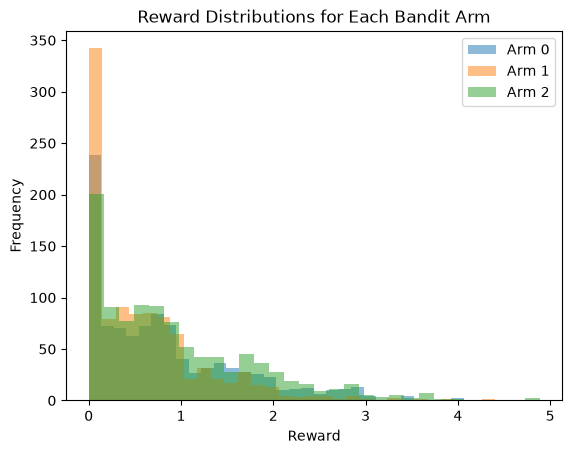

In [16]:
import matplotlib.pyplot as plt

for arm in range(bandit0.get_num_arms()):
    plt.hist(
        rewards[arm],
        bins=30,
        alpha=0.5,
        label=f"Arm {arm}"
    )

plt.xlabel("Reward")
plt.ylabel("Frequency")
plt.title("Reward Distributions for Each Bandit Arm")
plt.legend()
plt.show()

Based on your investigation, pick an appropriate bandit algorithm to implement from the algorithms covered this week.
Write a file "algorithm-choice.txt" that states your choice and give a single sentence justifying your choice and rejecting the alternatives.
Keep your explanation concise; you should be able to justify your choice solely based on the type of numbers observed, and whether those match the bandit algorithms that you have learned.

## Part 2: Implement Bandit

Based on your decision, implement an appropriate bandit algorithm and pick 1000 actions using seed 2026.

In [29]:
import numpy as np
import pandas as pd

bandit = BanditProblem(seed=2026)

num_actions = 1000
num_arms = bandit.get_num_arms()

counts = np.zeros(num_arms)
estimated_rewards = np.zeros(num_arms)

actions = []
rewards = []

# Pull each arm once initially
for arm in range(num_arms):
    reward = bandit.get_reward(arm)

    actions.append(arm)
    rewards.append(reward)

    counts[arm] += 1
    estimated_rewards[arm] = reward

# UCB
for t in range(num_arms, num_actions):

    ucb_values = estimated_rewards + np.sqrt(
        2 * np.log(t + 1) / counts
    )

    arm = np.argmax(ucb_values)

    reward = bandit.get_reward(arm)

    actions.append(int(arm))
    rewards.append(reward)

    counts[arm] += 1

    estimated_rewards[arm] += (
        reward - estimated_rewards[arm]
    ) / counts[arm]

In [30]:
print("Number of times each arm was selected:", counts)
print("Estimated rewards:", estimated_rewards)
print("First 20 actions:", actions[:20])

Number of times each arm was selected: [979.  11.  10.]
Estimated rewards: [1.21682864 0.16606783 0.12567672]
First 20 actions: [0, 1, 2, 0, 0, 0, 0, 0, 0, 0, 2, 1, 0, 0, 0, 0, 0, 0, 0, 0]


In [31]:
history = pd.DataFrame({
    "action": actions,
    "reward": rewards
})

history.to_csv("history.tsv", sep="\t", index=False)

print("Counts:", counts)
print("Estimated rewards:", estimated_rewards)
print("Total reward:", history["reward"].sum())

Counts: [979.  11.  10.]
Estimated rewards: [1.21682864 0.16606783 0.12567672]
Total reward: 1194.3587521025709


Write a file "history.tsv" with columns action and reward in the order that the actions were taken.

Submit "history.tsv" in Gradescope.

## Part 3: Action Statistics

Based on the data from part 2, estimate the expected reward for each arm and write a file "actions.tsv" with the columns action, min_reward, mean_reward, max_reward.

In [32]:
# YOUR CHANGES HERE

actions_summary = (
    history
    .groupby("action")["reward"]
    .agg(
        min_reward="min",
        mean_reward="mean",
        max_reward="max"
    )
    .reset_index()
)

actions_summary.to_csv(
    "actions.tsv",
    sep="\t",
    index=False
)

print(actions_summary)

   action  min_reward  mean_reward  max_reward
0       0         0.0     1.216829    6.564312
1       1         0.0     0.166068    0.623193
2       2         0.0     0.125677    0.958464


In [33]:
actions_summary.to_csv("actions.tsv", sep="\t", index=False)

Submit "actions.tsv" in Gradescope.

## Part 4: Regret Estimates

Estimate the regret taking 1000 actions with the following strategies.

* uniform: Pick an arm uniformly at random.
* just-i: Always pick arm $i$. Do this for $i=0$ to $K-1$ where $K$ is the number of arms.
* actual: This should match your output in part 2.

These estimates should be based on your previous action statistics; you should not use the true action values from the bandit code.

In [34]:
mean_rewards = (
    actions_summary
    .set_index("action")["mean_reward"]
)

num_actions = 1000
best_mean = mean_rewards.max()

optimal_total_reward = num_actions * best_mean

regrets = {}

# Uniform
uniform_expected_reward = (
    num_actions * mean_rewards.mean()
)

regrets["uniform"] = (
    optimal_total_reward - uniform_expected_reward
)

# Always choose arm i
for arm in mean_rewards.index:
    expected_reward = (
        num_actions * mean_rewards.loc[arm]
    )

    regrets[f"just-{arm}"] = (
        optimal_total_reward - expected_reward
    )

# Actual UCB strategy
actual_counts = history["action"].value_counts()

actual_expected_reward = sum(
    actual_counts.get(arm, 0) * mean_rewards.loc[arm]
    for arm in mean_rewards.index
)

regrets["actual"] = (
    optimal_total_reward - actual_expected_reward
)

# Save
strategies = pd.DataFrame({
    "strategy": list(regrets.keys()),
    "regret": list(regrets.values())
})

strategies.to_csv(
    "strategies.tsv",
    sep="\t",
    index=False
)

print(strategies)

  strategy       regret
0  uniform   713.970910
1   just-0     0.000000
2   just-1  1050.760808
3   just-2  1091.151923
4   actual    22.469888


Write your results to a file "strategies.tsv" with the columns strategy and regret.

In [35]:
# YOUR CHANGES HERE
strategies = pd.DataFrame({
    "strategy": list(regrets.keys()),
    "regret": list(regrets.values())
})
strategies.to_csv(
    "strategies.tsv",
    sep="\t",
    index=False
)

print(strategies)

  strategy       regret
0  uniform   713.970910
1   just-0     0.000000
2   just-1  1050.760808
3   just-2  1091.151923
4   actual    22.469888


Submit "strategies.tsv" in Gradescope.

## Part 5: Acknowledgments

Make a file "acknowledgments.txt" documenting any outside sources or help on this project.
If you discussed this assignment with anyone, please acknowledge them here.
If you used any libraries not mentioned in this module's content, please list them with a brief explanation what you used them for.
If you used any generative AI tools, please add links to your transcripts below, and any other information that you feel is necessary to comply with the generative AI policy.
If no acknowledgements are appropriate, just write none in the file.


Submit "acknowledgments.txt" in Gradescope.

## Part 6: Code

Please submit a Jupyter notebook that can reproduce all your calculations and recreate the previously submitted files.

Submit "project.ipynb" in Gradescope.